In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from IPython.display import display

# -----------------------
# user settings
# -----------------------

U_ID = "U333"

AUDITORY_ROOT = Path("/home/ganchao/isilon/AllStaff/auditory/m96z")
MUA_PATH = AUDITORY_ROOT / f"m96z_{U_ID}_playback_mua.mat"

DCF_ROOT = Path("/home/ganchao/isilon/AllStaff/DCF")
DCF_DATA_ROOT = DCF_ROOT / "data"

SMOOTH_SIGMA = 5.0
TRIM_START = 25

BAD_CHANNEL_STD_THR = 1e-8

CALL_SPECS = {
    "phee": {
        "pbdata_key": "phee",
        "folder_name": "phee",
    },
    "twitter": {
        "pbdata_key": "twitter",
        "folder_name": "twitter",
    },
    "trill": {
        "pbdata_key": "trill",
        "folder_name": "trill",
    },
    "trill_phee": {
        "pbdata_key": "trilphee",
        "folder_name": "trill_phee",
    },
}

SAVE_FIGURES = True

print("U_ID:", U_ID)
print("MUA_PATH:", MUA_PATH, MUA_PATH.exists())
print("DCF_DATA_ROOT:", DCF_DATA_ROOT, DCF_DATA_ROOT.exists())

assert U_ID == "U333"
assert MUA_PATH.exists()

U_ID: U333
MUA_PATH: /home/ganchao/isilon/AllStaff/auditory/m96z/m96z_U333_playback_mua.mat True
DCF_DATA_ROOT: /home/ganchao/isilon/AllStaff/DCF/data True


In [2]:
def load_pbdata(path):
    mat = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
        simplify_cells=True,
    )
    return mat["pbdata"]

pbdata = load_pbdata(MUA_PATH)

sample_rate = float(pbdata["sample_rate"])
prestim = float(pbdata["prestim"])
poststim = float(pbdata["poststim"])

print("pbdata keys:")
print(pbdata.keys())

print("sample_rate:", sample_rate)
print("prestim:", prestim)
print("poststim:", poststim)

pbdata keys:
dict_keys(['format', 'info', 'info2', 'info3', 'prestim', 'poststim', 'sample_rate', 'phee', 'twitter', 'trill', 'trilphee'])
sample_rate: 1220.703125
prestim: 500.0
poststim: 500.0


In [3]:
def extract_call_raw(pbdata, call_key, call_name):
    call_block = pbdata[call_key]

    vocfiles = np.asarray(call_block["vocfiles"]).astype(str)
    durations_ms = np.asarray(call_block["duration"], dtype=float)

    n_channel = len(call_block["mua"])
    n_stim = len(vocfiles)

    all_stim_arrays = []
    sample_rows = []

    for stim_idx, vocfile in enumerate(vocfiles):
        channel_arrays = []

        for ch_idx, ch_data in enumerate(call_block["mua"]):
            arr = np.asarray(ch_data[stim_idx], dtype=np.float32)

            if arr.ndim == 1:
                arr = arr[None, :]

            channel_arrays.append(arr)

        n_trials_stim = min(arr.shape[0] for arr in channel_arrays)
        n_T_stim = min(arr.shape[1] for arr in channel_arrays)

        X_stim = np.stack(
            [arr[:n_trials_stim, :n_T_stim] for arr in channel_arrays],
            axis=0,
        )  # channel x trial x time

        X_stim = np.transpose(X_stim, (1, 2, 0))  # trial x time x channel

        all_stim_arrays.append(X_stim)

        for trial_idx in range(n_trials_stim):
            sample_rows.append({
                "sample_idx": len(sample_rows),
                "call_type": call_name,
                "stim_idx": int(stim_idx),
                "trial_idx": int(trial_idx),
                "vocfile": str(vocfile),
                "duration_ms": float(durations_ms[stim_idx]),
                "original_T": int(n_T_stim),
            })

    n_T = min(x.shape[1] for x in all_stim_arrays)

    X = np.concatenate(
        [x[:, :n_T, :] for x in all_stim_arrays],
        axis=0,
    ).astype(np.float32)

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    time_ms = np.arange(n_T) / sample_rate * 1000.0 - prestim

    meta_df = pd.DataFrame(sample_rows)

    return {
        "call_name": call_name,
        "call_key": call_key,
        "X_raw": X,
        "time_ms": time_ms.astype(np.float32),
        "vocfiles": vocfiles,
        "durations_ms": durations_ms.astype(np.float32),
        "meta_df": meta_df,
        "n_channel": n_channel,
        "n_stim": n_stim,
    }

In [4]:
call_data = {}

for call_name, spec in CALL_SPECS.items():
    out = extract_call_raw(
        pbdata=pbdata,
        call_key=spec["pbdata_key"],
        call_name=call_name,
    )

    call_data[call_name] = out

    print()
    print(call_name)
    print("  pbdata key:", spec["pbdata_key"])
    print("  X_raw:", out["X_raw"].shape)
    print("  n stimuli:", out["n_stim"])
    print("  n samples:", out["X_raw"].shape[0])
    print("  n channels:", out["X_raw"].shape[2])


phee
  pbdata key: phee
  X_raw: (50, 2515, 32)
  n stimuli: 10
  n samples: 50
  n channels: 32

twitter
  pbdata key: twitter
  X_raw: (50, 2032, 32)
  n stimuli: 10
  n samples: 50
  n channels: 32

trill
  pbdata key: trill
  X_raw: (50, 1441, 32)
  n stimuli: 10
  n samples: 50
  n channels: 32

trill_phee
  pbdata key: trilphee
  X_raw: (50, 2406, 32)
  n stimuli: 10
  n samples: 50
  n channels: 32


In [5]:
# Use a common channel mask across all call types.
# This keeps dimensions aligned across phee/twitter/trill/trill_phee.

all_flat = []

for call_name, out in call_data.items():
    X = out["X_raw"]
    all_flat.append(X.reshape(-1, X.shape[-1]))

all_flat = np.concatenate(all_flat, axis=0)

ch_std_global = all_flat.std(axis=0)
good_ch = ch_std_global > BAD_CHANNEL_STD_THR
kept_channel_idx = np.where(good_ch)[0]
removed_channel_idx = np.where(~good_ch)[0]

print("kept channels:", good_ch.sum(), "/", good_ch.size)
print("removed channels:", removed_channel_idx.tolist())

assert good_ch.sum() > 0

kept channels: 30 / 32
removed channels: [1, 17]


In [6]:
def preprocess_one_call(out, good_ch, trim_start, smooth_sigma):
    X_raw = out["X_raw"]
    time_ms = out["time_ms"]

    assert trim_start < X_raw.shape[1]

    X_raw_good_trim = X_raw[:, trim_start:, :][:, :, good_ch].astype(np.float32)
    time_ms_trim = time_ms[trim_start:]

    X_smooth_raw_trim = gaussian_filter1d(
        X_raw_good_trim,
        sigma=smooth_sigma,
        axis=1,
        mode="nearest",
    ).astype(np.float32)

    smooth_mean = X_smooth_raw_trim.mean(axis=(0, 1), keepdims=True)
    smooth_std = X_smooth_raw_trim.std(axis=(0, 1), keepdims=True) + 1e-8

    X_smooth_z_trim = ((X_smooth_raw_trim - smooth_mean) / smooth_std).astype(np.float32)

    return {
        "X_raw_good_trim": X_raw_good_trim,
        "X_smooth_raw_trim": X_smooth_raw_trim,
        "X_smooth_z_trim": X_smooth_z_trim,
        "time_ms_trim": time_ms_trim.astype(np.float32),
        "smooth_mean": smooth_mean.squeeze().astype(np.float32),
        "smooth_std": smooth_std.squeeze().astype(np.float32),
    }


for call_name in call_data:
    proc = preprocess_one_call(
        out=call_data[call_name],
        good_ch=good_ch,
        trim_start=TRIM_START,
        smooth_sigma=SMOOTH_SIGMA,
    )

    call_data[call_name].update(proc)

    print()
    print(call_name)
    print("  raw     :", proc["X_raw_good_trim"].shape)
    print("  smooth  :", proc["X_smooth_raw_trim"].shape)
    print("  smooth_z:", proc["X_smooth_z_trim"].shape)
    print("  trim start ms:", proc["time_ms_trim"][0])


phee
  raw     : (50, 2490, 30)
  smooth  : (50, 2490, 30)
  smooth_z: (50, 2490, 30)
  trim start ms: -479.52

twitter
  raw     : (50, 2007, 30)
  smooth  : (50, 2007, 30)
  smooth_z: (50, 2007, 30)
  trim start ms: -479.52

trill
  raw     : (50, 1416, 30)
  smooth  : (50, 1416, 30)
  smooth_z: (50, 1416, 30)
  trim start ms: -479.52

trill_phee
  raw     : (50, 2381, 30)
  smooth  : (50, 2381, 30)
  smooth_z: (50, 2381, 30)
  trim start ms: -479.52


In [7]:
summary_rows = []

for call_name, out in call_data.items():
    X_raw = out["X_raw_good_trim"]
    X_smooth = out["X_smooth_raw_trim"]
    X_z = out["X_smooth_z_trim"]

    summary_rows.append({
        "call_type": call_name,
        "n_sample": X_raw.shape[0],
        "T": X_raw.shape[1],
        "n_channel": X_raw.shape[2],
        "raw_mean": float(X_raw.mean()),
        "smooth_mean": float(X_smooth.mean()),
        "smooth_z_mean": float(X_z.mean()),
        "smooth_z_std": float(X_z.std()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

assert summary_df["n_channel"].nunique() == 1

,call_type,n_sample,T,n_channel,raw_mean,smooth_mean,smooth_z_mean,smooth_z_std
0,phee,50,2490,30,42.053219,42.052437,0.000005,1.000012
1,twitter,50,2007,30,42.015343,42.014576,-0.000005,1.000008
2,trill,50,1416,30,42.544254,42.543190,0.000007,1.000006
3,trill_phee,50,2381,30,42.534702,42.534874,0.000012,1.000010


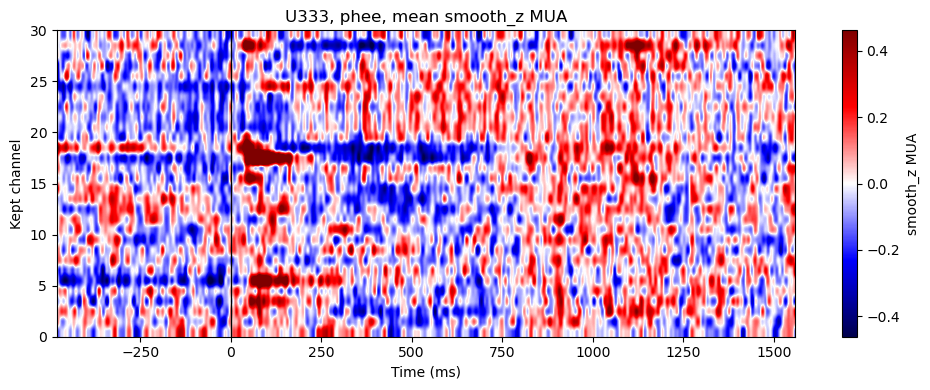

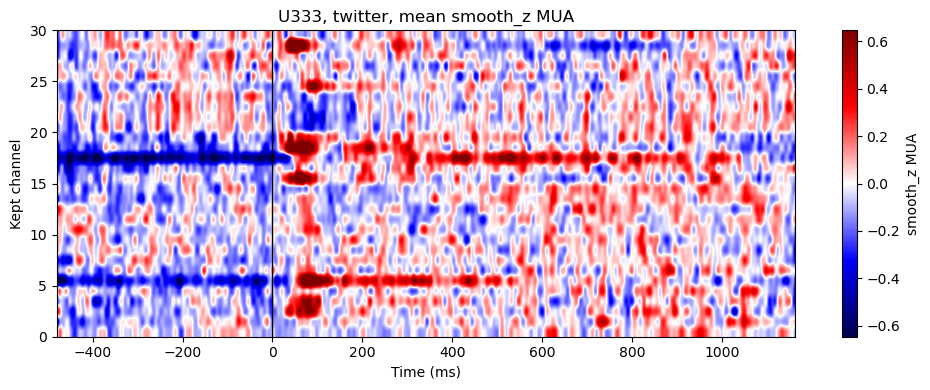

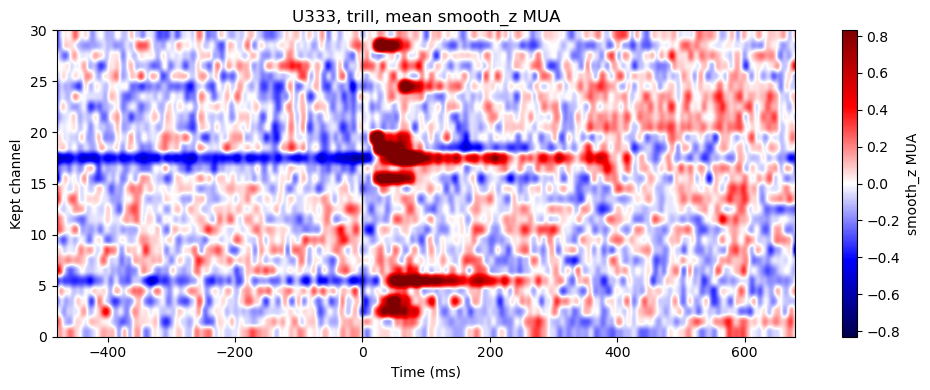

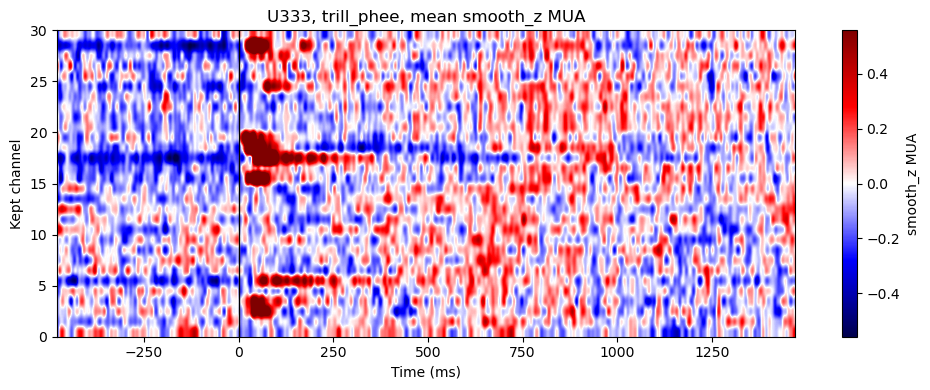

In [8]:
def plot_mean_heatmap(X, time_ms, title, value_label, center=False):
    mean_trial = X.mean(axis=0)  # time x channel
    heat = mean_trial.T          # channel x time

    fig, ax = plt.subplots(figsize=(10, 4))

    if center:
        vmax = np.percentile(np.abs(heat), 99)
        vmin = -vmax
        cmap = "seismic"
    else:
        vmin = np.percentile(heat, 1)
        vmax = np.percentile(heat, 99)
        cmap = None

    im = ax.imshow(
        heat,
        aspect="auto",
        origin="lower",
        extent=[time_ms[0], time_ms[-1], 0, heat.shape[0]],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.axvline(0, color="k", linewidth=1)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Kept channel")
    ax.set_title(title)

    fig.colorbar(im, ax=ax, label=value_label)
    fig.tight_layout()
    plt.show()


for call_name, out in call_data.items():
    plot_mean_heatmap(
        out["X_smooth_z_trim"],
        out["time_ms_trim"],
        title=f"{U_ID}, {call_name}, mean smooth_z MUA",
        value_label="smooth_z MUA",
        center=True,
    )

In [9]:
def save_dcf_call_folders(call_name, out):
    folder_name = CALL_SPECS[call_name]["folder_name"]

    # Main compatibility folder:
    # dataset_samples.npz = smooth_z, matching the old twitter notebook behavior.
    main_out_dir = DCF_DATA_ROOT / f"m96z_{U_ID}_{folder_name}_all"
    main_out_dir.mkdir(parents=True, exist_ok=True)

    X_raw = out["X_raw_good_trim"]
    X_smooth = out["X_smooth_raw_trim"]
    X_z = out["X_smooth_z_trim"]

    time_ms_trim = out["time_ms_trim"]

    np.savez(
        main_out_dir / "dataset_samples_raw.npz",
        samples=X_raw.astype(np.float32),
    )

    np.savez(
        main_out_dir / "dataset_samples_smooth_raw.npz",
        samples=X_smooth.astype(np.float32),
    )

    np.savez(
        main_out_dir / "dataset_samples.npz",
        samples=X_z.astype(np.float32),
    )

    meta_df_save = out["meta_df"].copy()
    meta_df_save["saved_T"] = int(X_z.shape[1])
    meta_df_save["trim_start_bins"] = int(TRIM_START)
    meta_df_save["trim_start_ms"] = float(out["time_ms"][TRIM_START])
    meta_df_save.to_csv(main_out_dir / "sample_metadata.csv", index=False)

    base_meta = {
        "u_id": U_ID,
        "call_type": call_name,
        "pbdata_key": out["call_key"],
        "vocfiles": out["vocfiles"],
        "durations_ms": out["durations_ms"],

        "sample_rate": float(sample_rate),
        "prestim": float(prestim),
        "poststim": float(poststim),

        "time_ms": time_ms_trim.astype(np.float32),
        "original_time_ms": out["time_ms"].astype(np.float32),

        "trim_start_bins": int(TRIM_START),
        "trim_start_ms": float(out["time_ms"][TRIM_START]),

        "format": "[n_sample, T, n_channel]",
        "raw_shape_before_filter": out["X_raw"].shape,
        "raw_filtered_shape": X_raw.shape,
        "smooth_raw_shape": X_smooth.shape,
        "processed_shape": X_z.shape,

        "good_ch": good_ch,
        "kept_channel_idx": kept_channel_idx,
        "removed_channel_idx": removed_channel_idx,

        "bad_channel_threshold_std": float(BAD_CHANNEL_STD_THR),
        "smooth_sigma_bins": float(SMOOTH_SIGMA),
        "smooth_sigma_ms": float(SMOOTH_SIGMA * np.median(np.diff(out["time_ms"]))),

        "smooth_mean": out["smooth_mean"],
        "smooth_std": out["smooth_std"],
    }

    meta = dict(base_meta)
    meta["variant"] = "smooth_z"
    meta["variant_description"] = "Gaussian-smoothed raw MUA, channel-wise standardized after trimming"
    meta["saved_shape"] = X_z.shape

    np.save(main_out_dir / "metadata.npy", meta, allow_pickle=True)

    variant_data = {
        "raw": X_raw,
        "smooth": X_smooth,
        "smooth_z": X_z,
    }

    variant_desc = {
        "raw": "raw MUA after common bad-channel filtering and trimming",
        "smooth": "Gaussian-smoothed raw MUA after common bad-channel filtering and trimming",
        "smooth_z": "Gaussian-smoothed raw MUA, channel-wise standardized after trimming",
    }

    saved_dirs = {}

    for variant_name, X_save in variant_data.items():
        this_out_dir = DCF_DATA_ROOT / f"m96z_{U_ID}_{folder_name}_all_{variant_name}"
        this_out_dir.mkdir(parents=True, exist_ok=True)

        np.savez(
            this_out_dir / "dataset_samples.npz",
            samples=X_save.astype(np.float32),
        )

        meta_df_save.to_csv(this_out_dir / "sample_metadata.csv", index=False)

        this_meta = dict(base_meta)
        this_meta["variant"] = variant_name
        this_meta["variant_description"] = variant_desc[variant_name]
        this_meta["saved_shape"] = X_save.shape

        np.save(this_out_dir / "metadata.npy", this_meta, allow_pickle=True)

        saved_dirs[variant_name] = this_out_dir

    return main_out_dir, saved_dirs


all_saved = {}

for call_name, out in call_data.items():
    main_out, saved_dirs = save_dcf_call_folders(call_name, out)
    all_saved[call_name] = {
        "main": main_out,
        **saved_dirs,
    }

    print()
    print(call_name)
    print("  main    :", main_out)
    for variant, path in saved_dirs.items():
        print(f"  {variant:8s}:", path)


phee
  main    : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_phee_all
  raw     : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_phee_all_raw
  smooth  : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_phee_all_smooth
  smooth_z: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_phee_all_smooth_z

twitter
  main    : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_twitter_all
  raw     : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_twitter_all_raw
  smooth  : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_twitter_all_smooth
  smooth_z: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_twitter_all_smooth_z

trill
  main    : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_trill_all
  raw     : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_trill_all_raw
  smooth  : /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_trill_all_smooth
  smooth_z: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U333_trill_all_smooth_z

trill_phee
  main    : /home/ganchao/isilon/AllStaff/DCF/data

In [10]:
verify_rows = []

for call_name, paths in all_saved.items():
    for variant, path in paths.items():
        data_path = path / "dataset_samples.npz"
        meta_path = path / "metadata.npy"

        assert data_path.exists(), data_path
        assert meta_path.exists(), meta_path

        X_load = np.load(data_path, allow_pickle=True)["samples"]
        meta = np.load(meta_path, allow_pickle=True).item()

        verify_rows.append({
            "call_type": call_name,
            "variant": variant,
            "path": str(path),
            "shape": X_load.shape,
            "meta_variant": meta.get("variant"),
            "n_sample": X_load.shape[0],
            "T": X_load.shape[1],
            "D": X_load.shape[2],
        })

verify_df = pd.DataFrame(verify_rows)
display(verify_df)

,call_type,variant,path,shape,meta_variant,n_sample,T,D
0,phee,main,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2490, 30)",smooth_z,50,2490,30
1,phee,raw,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2490, 30)",raw,50,2490,30
2,phee,smooth,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2490, 30)",smooth,50,2490,30
3,phee,smooth_z,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2490, 30)",smooth_z,50,2490,30
4,twitter,main,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2007, 30)",smooth_z,50,2007,30
5,twitter,raw,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2007, 30)",raw,50,2007,30
6,twitter,smooth,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2007, 30)",smooth,50,2007,30
7,twitter,smooth_z,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 2007, 30)",smooth_z,50,2007,30
8,trill,main,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 1416, 30)",smooth_z,50,1416,30
9,trill,raw,/home/ganchao/isilon/AllStaff/DCF/data/m96z_U3...,"(50, 1416, 30)",raw,50,1416,30


In [11]:
print("Use these --data_path values from the DCF repo root:\n")

for call_name in CALL_SPECS:
    folder_name = CALL_SPECS[call_name]["folder_name"]

    print(call_name)
    print(f"  raw      data/m96z_{U_ID}_{folder_name}_all_raw")
    print(f"  smooth   data/m96z_{U_ID}_{folder_name}_all_smooth")
    print(f"  smooth_z data/m96z_{U_ID}_{folder_name}_all_smooth_z")
    print()

Use these --data_path values from the DCF repo root:

phee
  raw      data/m96z_U333_phee_all_raw
  smooth   data/m96z_U333_phee_all_smooth
  smooth_z data/m96z_U333_phee_all_smooth_z

twitter
  raw      data/m96z_U333_twitter_all_raw
  smooth   data/m96z_U333_twitter_all_smooth
  smooth_z data/m96z_U333_twitter_all_smooth_z

trill
  raw      data/m96z_U333_trill_all_raw
  smooth   data/m96z_U333_trill_all_smooth
  smooth_z data/m96z_U333_trill_all_smooth_z

trill_phee
  raw      data/m96z_U333_trill_phee_all_raw
  smooth   data/m96z_U333_trill_phee_all_smooth
  smooth_z data/m96z_U333_trill_phee_all_smooth_z

